In [2]:
#Import Libs
from matplotlib import pyplot as plot
import PIL.Image as Image
import matplotlib as mpl
import urllib.request
import urllib.parse
import numpy as np
import struct
import random
import math
import cv2
import io

In [3]:
#Function to Load a Image from Github
def display_image_from_url(image_url):
    with urllib.request.urlopen(image_url) as url:
        s = url.read()
    img = cv2.imdecode(np.frombuffer(s, np.uint8), -1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

In [4]:
#Import Image
image_url = 'https://raw.githubusercontent.com/jrafa1607/Computational-Vision-In-Python/main/-%20Images/Owl.bmp'
img = display_image_from_url(image_url)

### **Reading Classes**

BMP images can be divided into four parts:
 + File header;
 + Bitmap / DIB (Device Independent Bitmaps) header;
 + Color palette; and
 + Image data.

The **classes** defined below represent, respectively:
*   *file header*
*   *bitmap header*
*   *color palette*

| Line | Size | Name | Class | Fields |
|------|---------|------|--------|--------|
| 0 | 2 bytes | File header | `Cab` | Type |
| 1 | 4 bytes | File header | `Cab1` | Image size |
| 2 | 2 bytes | File header | `Cab1` | Reserved 1 |
| 3 | 2 bytes | File header | `Cab1` | Reserved 2 |
| 4 | 4 bytes | File header | `Cab1` | Image data offset |
| 5 | 4 bytes | Bitmap header | `Cab2` | Image header size |
| 6 | 4 bytes | Bitmap header | `Cab2` | Height |
| 7 | 4 bytes | Bitmap header | `Cab2` | Width |
| 8 | 2 bytes | Bitmap header | `Cab2` | Planes |
| 9 | 2 bytes | Bitmap header | `Cab2` | Bits per pixel |
| 10 | 4 bytes | Bitmap header | `Cab2` | Compression type |
| 11 | 4 bytes | Bitmap header | `Cab2` | Compressed image size |
| 12 | 4 bytes | Bitmap header | `Cab2` | Horizontal resolution |
| 13 | 4 bytes | Bitmap header | `Cab2` | Vertical resolution |
| 14 | 4 bytes | Bitmap header |`Cab2` | Max number of colors |
| 15 | 4 bytes | Bitmap header | `Cab2` | Number of colors used |
| 16 | 1 byte | Color palette | `Cab3` | Red |
| 17 | 1 byte | Color palette | `Cab3` | Green |
| 18 | 1 byte | Color palette | `Cab3` | Blue |
| 19 | 1 byte | Color palette | `Cab3` | Reserved |

In [5]:
#Function to Read the Classes
class Cab():
  def __init__(self, bmp):
    self.file_type = bmp.read(2).decode()

class Cab1():
  def __init__(self, bmp):
    self.image_size = struct.unpack('I', bmp.read(4))[0]
    self.reserved_1 = struct.unpack('H', bmp.read(2))[0]
    self.reserved_2 = struct.unpack('H', bmp.read(2))[0]
    self.image_data_offset = struct.unpack('I', bmp.read(4))[0]

class Cab2():
  def __init__(self, bmp):
    self.image_header_size = struct.unpack('I', bmp.read(4))[0]
    self.width = struct.unpack('I', bmp.read(4))[0]
    self.height = struct.unpack('I', bmp.read(4))[0]
    self.planes = struct.unpack('H', bmp.read(2))[0]
    self.bits_per_pixel = struct.unpack('H', bmp.read(2))[0]
    self.compression_type = struct.unpack('I', bmp.read(4))[0]
    self.compressed_image_size = struct.unpack('I', bmp.read(4))[0]
    self.horizontal_resolution = struct.unpack('I', bmp.read(4))[0]
    self.vertical_resolution = struct.unpack('I', bmp.read(4))[0]
    self.max_number_of_colors = struct.unpack('I', bmp.read(4))[0]
    self.number_of_colors_used = struct.unpack('I', bmp.read(4))[0]

class Cab3():
  def __init__(self, bmp):
    self.red = struct.unpack('B', bmp.read(1))[0]
    self.green = struct.unpack('B', bmp.read(1))[0]
    self.blue = struct.unpack('B', bmp.read(1))[0]
    self.reserv = struct.unpack('B', bmp.read(1))[0]

In [6]:
# Fetch the raw BMP bytes from the URL
with urllib.request.urlopen(image_url) as url:
    raw_bmp_bytes = url.read()

In [7]:
# Create an in-memory binary stream from the raw bytes
bmp_stream = io.BytesIO(raw_bmp_bytes)

In [8]:
# Read the signature, file header, and bitmap header from the stream
signature = Cab(bmp_stream)
file_header = Cab1(bmp_stream)
bitmap_header = Cab2(bmp_stream)

In [9]:
#Show All the Information about BMP Image
print('Type\t	:{}'.format(signature.file_type))

print('File Size\t: {}'.format(file_header.image_size))
print('Reserved 1\t: {}'.format(file_header.reserved_1))
print('Reserved 2\t: {}'.format(file_header.reserved_2))
print('Data Offset\t: {}'.format(file_header.image_data_offset))

print('\nBitmap Header')
print('Header Size\t: {}'.format(bitmap_header.image_header_size))
print('Image Width\t: {}'.format(bitmap_header.width))
print('Image Height\t: {}'.format(bitmap_header.height))
print('Number of Planes\t\t: {}'.format(bitmap_header.planes))
print('Bits per Pixel\t\t: {}'.format(bitmap_header.bits_per_pixel))
print('Compression Used\t: {}'.format(bitmap_header.compression_type))
print('Image Size (data)\t: {}'.format(bitmap_header.compressed_image_size))
print('Horizontal Resolution\t: {}'.format(bitmap_header.horizontal_resolution))
print('Vertical Resolution\t: {}'.format(bitmap_header.vertical_resolution))
print('Number of Used Colors\t\t: {}'.format(bitmap_header.max_number_of_colors))
print('Number of Important Colors\t: {}'.format(bitmap_header.number_of_colors_used))

Type		:BM
File Size	: 925966
Reserved 1	: 0
Reserved 2	: 0
Data Offset	: 62

Bitmap Header
Header Size	: 40
Image Width	: 3120
Image Height	: 2362
Number of Planes		: 1
Bits per Pixel		: 1
Compression Used	: 0
Image Size (data)	: 0
Horizontal Resolution	: 11806
Vertical Resolution	: 11806
Number of Used Colors		: 2
Number of Important Colors	: 2


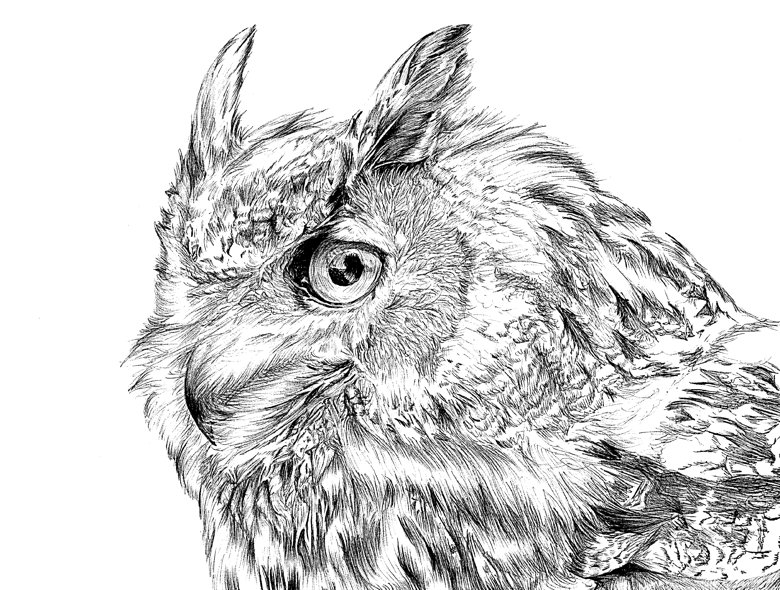

In [10]:
#Show the Image
image_pil = Image.fromarray(img)
width, height = image_pil.size

# Calculate new dimensions (half of current)
new_width = width // 4
new_height = height // 4

# Resize the image
image_pil = image_pil.resize((new_width, new_height))
image_pil

In [11]:
#Interpreting the Color Palette
num_colors = int(pow(2, bitmap_header.bits_per_pixel))

if num_colors <= 256 and file_header.image_data_offset > 54:
  for i in range(num_colors):
    palette = Cab3(bmp_stream)
    print('Color {0}: {1}\t {2}\t {3}\t {4}'.format(i, palette.red, palette.green, palette.blue, palette.reserv))

Color 0: 0	 0	 0	 255
Color 1: 255	 255	 255	 255
